# Capítulo 20 — Previsão Numérica do Tempo: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | esquemas de advecção: upwind, leapfrog, Lax–Wendroff e o CFL | NumPy |
| 2 | o caos de Lorenz (1963): por que a previsão tem prazo de validade | `solve_ivp` |
| 3 | assimilação de dados: misturar modelo e observação na medida certa | NumPy |
| 4 | previsão por conjunto (ensemble): do determinismo à probabilidade | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap20_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## Caso 1 — Advecção em grade: os pecados de cada esquema

A equação mais simples da previsão, $\partial_t\phi + U\partial_x\phi = 0$, já expõe tudo: difusão numérica (upwind), dispersão (leapfrog) e a condição **CFL** $|U|\Delta t/\Delta x \le 1$ — o limite de velocidade de qualquer modelo.

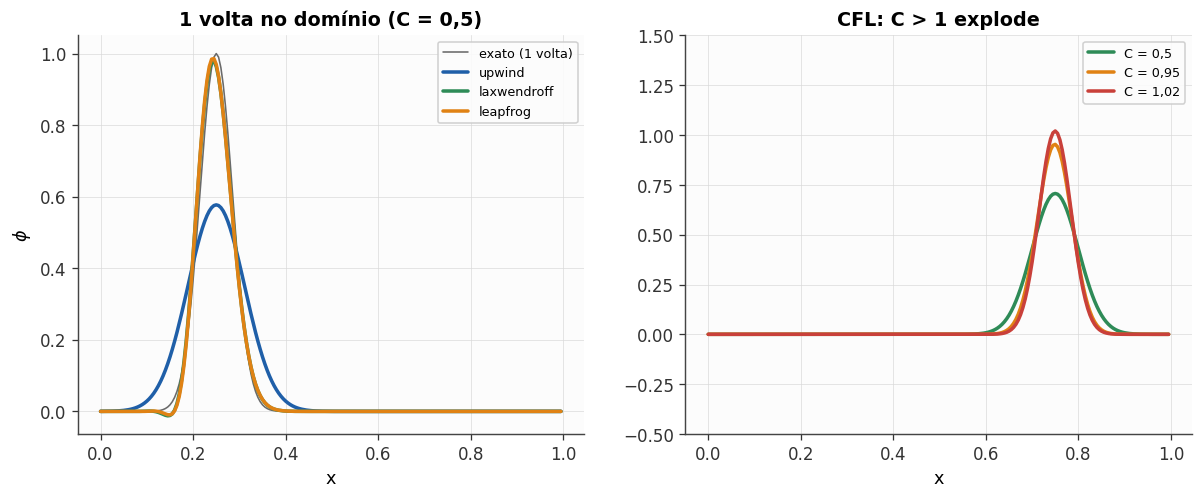

upwind: estavel e DIFUSIVO (a gaussiana derrete — Cap. 3, N3!);
Lax-Wendroff: preciso mas dispersivo (ondulas atras); leapfrog: modo computacional.
CFL: informacao nao pode pular celulas — dt < dx/U. Modelo global de 10 km:
dt < 33 s por causa das ondas de gravidade (~300 m/s).


In [2]:
nx, L, U = 200, 1.0, 1.0
dx = L/nx
x = np.arange(nx)*dx
phi0 = np.exp(-((x - 0.25)/0.05)**2)

def advecta(phi0, C, n_volta=1, esquema='upwind'):
    dt = C*dx/U
    nt = int(round(n_volta*L/(U*dt)))
    phi = phi0.copy()
    if esquema == 'leapfrog':
        phi_old = phi0.copy()
        phi = phi0 - C*(np.roll(phi0, -1) - np.roll(phi0, 1))/2   # passo Euler inicial
    for _ in range(nt - (1 if esquema == 'leapfrog' else 0)):
        if esquema == 'upwind':
            phi = phi - C*(phi - np.roll(phi, 1))
        elif esquema == 'laxwendroff':
            phi = (phi - C/2*(np.roll(phi, -1) - np.roll(phi, 1))
                   + C**2/2*(np.roll(phi, -1) - 2*phi + np.roll(phi, 1)))
        elif esquema == 'leapfrog':
            novo = phi_old - C*(np.roll(phi, -1) - np.roll(phi, 1))
            phi_old, phi = phi, novo
    return phi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax1.plot(x, phi0, color=CORES['cinza'], lw=1, label='exato (1 volta)')
for esq, cor in [('upwind', CORES['azul']), ('laxwendroff', CORES['verde']),
                  ('leapfrog', CORES['laranja'])]:
    ax1.plot(x, advecta(phi0, 0.5, 1, esq), color=cor, label=esq)
ax1.set(xlabel='x', ylabel='$\\phi$', title='1 volta no domínio (C = 0,5)')
ax1.legend(fontsize=8)
for C, cor in [(0.5, CORES['verde']), (0.95, CORES['laranja']), (1.02, CORES['vermelho'])]:
    phi = advecta(phi0, C, 0.5, 'upwind')
    ax2.plot(x, phi, color=cor, label=f'C = {C}'.replace('.', ','))
ax2.set(xlabel='x', title='CFL: C > 1 explode', ylim=(-0.5, 1.5))
ax2.legend(fontsize=8)
plt.show()
print('upwind: estavel e DIFUSIVO (a gaussiana derrete — Cap. 3, N3!);')
print('Lax-Wendroff: preciso mas dispersivo (ondulas atras); leapfrog: modo computacional.')
print('CFL: informacao nao pode pular celulas — dt < dx/U. Modelo global de 10 km:')
print(f'dt < {10e3/300:.0f} s por causa das ondas de gravidade (~300 m/s).')

## Caso 2 — Lorenz 1963: o prazo de validade da previsão

Três EDOs de convecção idealizada:
$$\dot X = \sigma(Y - X),\quad \dot Y = X(\rho - Z) - Y,\quad \dot Z = XY - \beta Z.$$
Dois estados iniciais indistinguíveis divergem exponencialmente: **caos determinístico** — a descoberta que transformou a meteorologia.

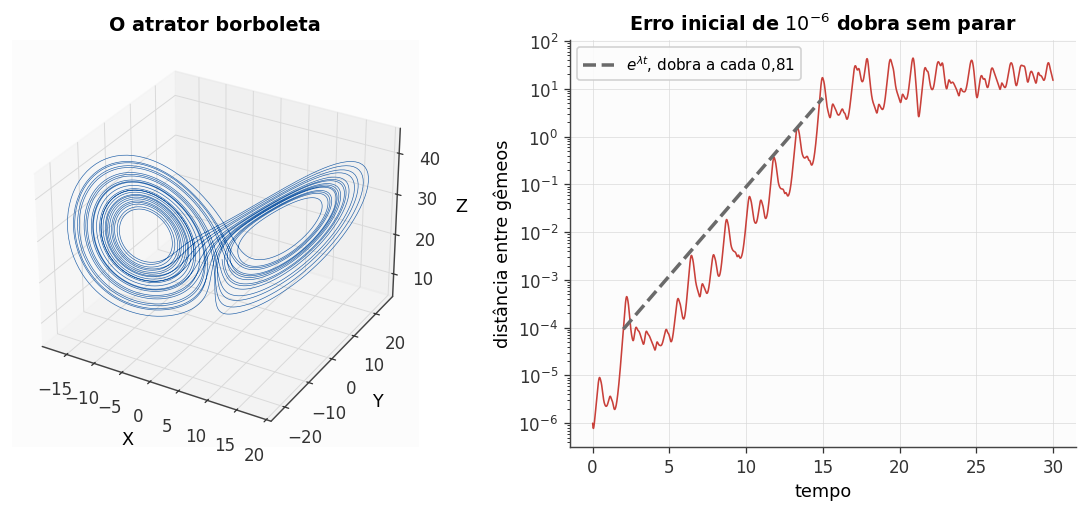

expoente de Lyapunov ~ 0.86 (dobra a cada 0.81 unidades):
na atmosfera real o erro dobra a cada ~2 dias -> alem de ~2 semanas,
nenhum computador preve o TEMPO (o CLIMA — a estatistica — sim: Cap. 21).


In [3]:
sig, rho, beta = 10.0, 28.0, 8/3
def lorenz(t, s):
    X, Y, Z = s
    return [sig*(Y - X), X*(rho - Z) - Y, X*Y - beta*Z]

t_span, t_eval = [0, 30], np.linspace(0, 30, 6000)
s1 = solve_ivp(lorenz, t_span, [1.0, 1.0, 20.0], t_eval=t_eval, rtol=1e-10)
s2 = solve_ivp(lorenz, t_span, [1.0 + 1e-6, 1.0, 20.0], t_eval=t_eval, rtol=1e-10)
dist = np.linalg.norm(s1.y - s2.y, axis=0)

fig = plt.figure(figsize=(12.5, 4.6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(*s1.y, lw=0.4, color=CORES['azul'])
ax1.set_title('O atrator borboleta')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax2 = fig.add_subplot(122)
ax2.semilogy(t_eval, dist, color=CORES['vermelho'], lw=1)
m = (t_eval > 2) & (t_eval < 15)
lam = np.polyfit(t_eval[m], np.log(dist[m]), 1)[0]
ax2.semilogy(t_eval[m], dist[m][0]*np.exp(lam*(t_eval[m] - t_eval[m][0])), '--',
             color=CORES['cinza'], label=f'$e^{{\\lambda t}}$, dobra a cada {np.log(2)/lam:.2f}'.replace('.', ','))
ax2.set(xlabel='tempo', ylabel='distância entre gêmeos',
        title='Erro inicial de $10^{-6}$ dobra sem parar')
ax2.legend()
plt.show()
print(f'expoente de Lyapunov ~ {lam:.2f} (dobra a cada {np.log(2)/lam:.2f} unidades):')
print('na atmosfera real o erro dobra a cada ~2 dias -> alem de ~2 semanas,')
print('nenhum computador preve o TEMPO (o CLIMA — a estatistica — sim: Cap. 21).')

## Caso 3 — Assimilação: a média ponderada mais importante do mundo

Análise = mistura ótima da previsão anterior (background $x_b$, erro $\sigma_b$) com a observação ($y_o$, erro $\sigma_o$):
$$x_a = x_b + K\,(y_o - x_b),\qquad K = \frac{\sigma_b^2}{\sigma_b^2 + \sigma_o^2}.$$
Ciclamos isso sobre o Lorenz: o modelo caótico é mantido na linha por observações ruidosas.

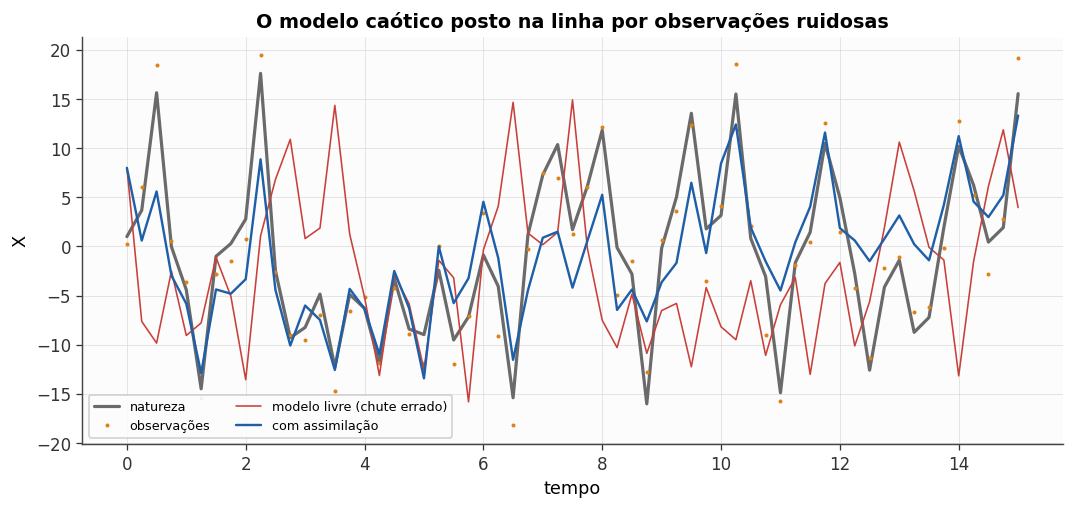

RMSE livre = 11.8 | com assimilacao = 4.9 (obs: 2.0) — a analise fica MELHOR que as observacoes,
porque carrega a memoria dinamica do modelo: a magica do 4D-Var/EnKF.


In [4]:
rng = np.random.default_rng(20)
dt_ciclo, T_tot, sigma_o = 0.25, 15.0, 2.0

# natureza (verdade) e observações de X
nat = solve_ivp(lorenz, [0, T_tot], [1.0, 1.0, 20.0],
                t_eval=np.arange(0, T_tot + 1e-9, dt_ciclo), rtol=1e-10)
obs = nat.y[0] + sigma_o*rng.standard_normal(nat.t.size)

def ciclo(assimila, K=0.6):
    x = np.array([8.0, -8.0, 27.0])            # chute inicial ERRADO
    tra = [x.copy()]
    for k in range(1, nat.t.size):
        s = solve_ivp(lorenz, [0, dt_ciclo], x, rtol=1e-10)
        x = s.y[:, -1]
        if assimila:
            x[0] = x[0] + K*(obs[k] - x[0])    # corrige só X observado
        tra.append(x.copy())
    return np.array(tra).T

livre = ciclo(False)
assim = ciclo(True)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(nat.t, nat.y[0], color=CORES['cinza'], lw=2, label='natureza')
ax.plot(nat.t, obs, '.', ms=3, color=CORES['laranja'], label='observações')
ax.plot(nat.t, livre[0], color=CORES['vermelho'], lw=1, label='modelo livre (chute errado)')
ax.plot(nat.t, assim[0], color=CORES['azul'], lw=1.5, label='com assimilação')
ax.set(xlabel='tempo', ylabel='X', title='O modelo caótico posto na linha por observações ruidosas')
ax.legend(fontsize=8, ncol=2)
plt.show()
e_livre = np.sqrt(np.mean((livre[0] - nat.y[0])**2))
e_assim = np.sqrt(np.mean((assim[0] - nat.y[0])**2))
print(f'RMSE livre = {e_livre:.1f} | com assimilacao = {e_assim:.1f} '
      f'(obs: {sigma_o}) — a analise fica MELHOR que as observacoes,')
print('porque carrega a memoria dinamica do modelo: a magica do 4D-Var/EnKF.')

## Caso 4 — Ensemble: prever a própria incerteza

Se um chute inicial é ilusão, rodamos 30: a **dispersão** do conjunto é a barra de erro da previsão — e a fração de membros num estado vira **probabilidade**.

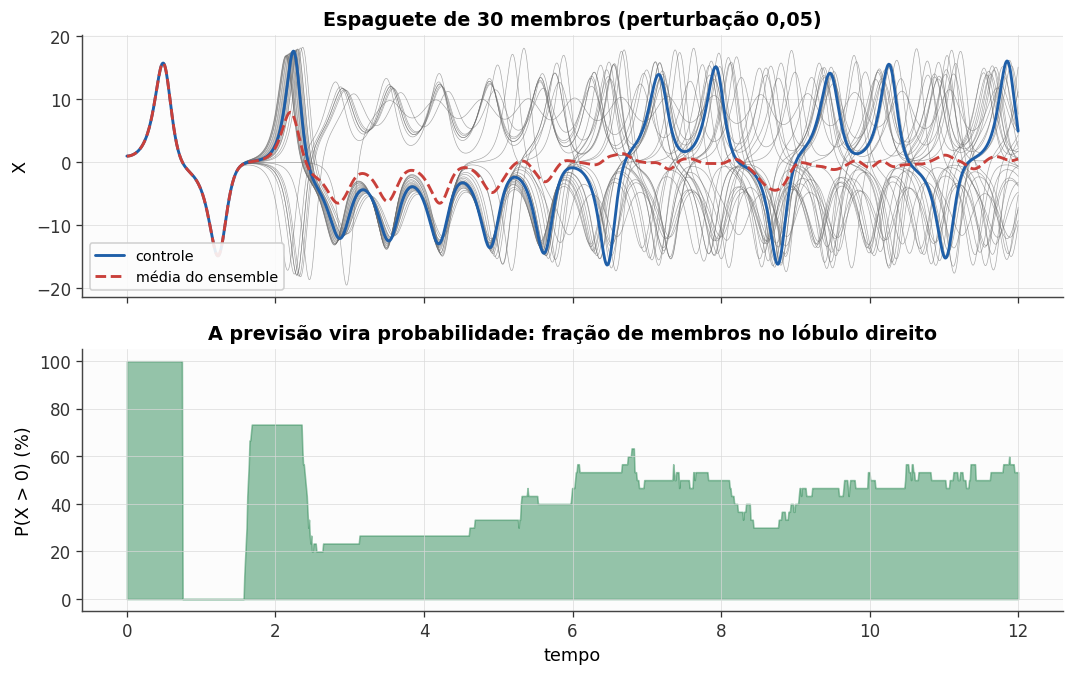

a dispersao explode em t ~ 2.1: fim do horizonte deterministico;
depois disso so a probabilidade tem valor — exatamente como o ECMWF/GFS operam.


In [5]:
rng = np.random.default_rng(7)
n_memb = 30
x0 = np.array([1.0, 1.0, 20.0])
t_eval = np.linspace(0, 12, 1200)
membros = []
for _ in range(n_memb):
    pert = x0 + 0.05*rng.standard_normal(3)
    membros.append(solve_ivp(lorenz, [0, 12], pert, t_eval=t_eval, rtol=1e-10).y[0])
membros = np.array(membros)
controle = solve_ivp(lorenz, [0, 12], x0, t_eval=t_eval, rtol=1e-10).y[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
ax1.plot(t_eval, membros.T, color=CORES['cinza'], lw=0.4, alpha=0.6)
ax1.plot(t_eval, controle, color=CORES['azul'], lw=1.8, label='controle')
ax1.plot(t_eval, membros.mean(0), color=CORES['vermelho'], lw=1.8, ls='--',
         label='média do ensemble')
ax1.set(ylabel='X', title=f'Espaguete de {n_memb} membros (perturbação 0,05)')
ax1.legend(fontsize=9)
prob = (membros > 0).mean(axis=0)
ax2.fill_between(t_eval, prob*100, color=CORES['verde'], alpha=0.5)
ax2.set(xlabel='tempo', ylabel='P(X > 0) (%)',
        title='A previsão vira probabilidade: fração de membros no lóbulo direito')
plt.show()
spread = membros.std(axis=0)
i_util = np.argmax(spread > 0.7*membros.std())
print(f'a dispersao explode em t ~ {t_eval[i_util]:.1f}: fim do horizonte deterministico;')
print('depois disso so a probabilidade tem valor — exatamente como o ECMWF/GFS operam.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap20_solucoes.ipynb`**.

**N1** — Meça a difusão numérica do upwind: ajuste uma gaussiana à solução após 1 volta para vários $C$ e compare a largura com a previsão $K_{num} = U\Delta x(1-C)/2$ (T2).

**N2** — Estime o expoente de Lyapunov do Lorenz por regressão para 20 pares de gêmeos com sementes diferentes; reporte média e desvio.

**N3** — No ciclo de assimilação, varra o ganho $K$ de 0 a 1 e trace o RMSE da análise; compare o ótimo empírico com $K^* = \sigma_b^2/(\sigma_b^2+\sigma_o^2)$ estimando $\sigma_b$ da própria série (T4).

**N4** — Verifique a relação dispersão-erro do ensemble: para 50 previsões independentes (janelas diferentes do atrator), correlacione o spread em $t = 5$ com o erro da média do ensemble; o ensemble 'sabe' quando vai errar?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*